# Exploratory Data Analysis

## Health Report for downloaded datasets

In [20]:
import pandas as pd
from ai_waf_v2.data import WafDataset

### CS-IC-2010

#### Basic Inspection from csv file

In [36]:
# Load a sample to avoid OOM (Out of Memory errors)
df = pd.read_csv('../data/raw/csic_2010.csv', nrows=100000)
print(f"--- Dataset: CS-IC-2010 ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['classification'].unique())

print("\n--- Unique Labels ---")
print(df['Unnamed: 0'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['classification', 'Unnamed: 0']).size().reset_index(name='count'))



--- Dataset: CS-IC-2010 ---
Columns: ['Unnamed: 0', 'Method', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host', 'cookie', 'content-type', 'connection', 'lenght', 'content', 'classification', 'URL']

--- Rows ---
61065

--- Unique Categories ---
[0 1]

--- Unique Labels ---
['Normal' 'Anomalous']

--- Distribution (Counts) ---
   classification Unnamed: 0  count
0               0     Normal  36000
1               1  Anomalous  25065


#### Inspection of parquet file

In [40]:
df = pd.read_parquet("../data/normalized/CSIC 2010.parquet")
print(f"--- Dataset: CS-IC-2010 ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

--- Dataset: CS-IC-2010 ---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
61065

--- Unique Categories ---
['benign' 'unknown']

--- Unique Labels ---
[0 1]

--- Distribution (Counts) ---
  attack_class  label  count
0       benign      0  36000
1      unknown      1  25065


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
15729,c11e9467-0523-4b19-90b4-a2683f4c597b,GET,http://localhost:8080/tienda1/imagenes/cmenbul.gif HTTP/1.1,,{},,GET http://localhost:8080/tienda1/imagenes/cmenbul.gif HTTP/1.1 HTTP/1.1\r\n,0,benign,CSIC 2010,
58200,6b257d15-4150-47d5-a2d7-c5881fbf5c73,GET,http://localhost:8080/tienda1/miembros/editar.jsp,modo=registro&login=cray&passwordA=parenq35395028&nombre=Walda&apellidos=Bret&email=abel%40intapisur.lt&dni=00602599E&direccion=Cuenca+S%2FN+&ciudad=Castro+del+R%EDo&cp=03679&provincia=Burgos&ntc=0570981782907546&B1=Registrar HTTP/1.1,{},,GET http://localhost:8080/tienda1/miembros/editar.jsp?modo=registro&login=cray&passwordA=parenq35395028&nombre=Walda&apellidos=Bret&email=abel%40intapisur.lt&dni=00602599E&direccion=Cuenca+S%2FN+&ciudad=Castro+del+R%EDo&cp=03679&provincia=Burgos&ntc=0570981782907546&B1=Registrar HTTP/1.1 HTTP/1.1\r\n,1,unknown,CSIC 2010,
18220,dbee81d7-e594-48e8-bc11-63ca9412f925,POST,http://localhost:8080/tienda1/publico/autenticar.jsp HTTP/1.1,,{},,POST http://localhost:8080/tienda1/publico/autenticar.jsp HTTP/1.1 HTTP/1.1\r\n,0,benign,CSIC 2010,
55454,af1f5201-ef2e-49c4-95a4-3d5bd6cfe2ac,POST,http://localhost:8080/tienda1/publico/caracteristicas.jsp HTTP/1.1,,{},,POST http://localhost:8080/tienda1/publico/caracteristicas.jsp HTTP/1.1 HTTP/1.1\r\n,1,unknown,CSIC 2010,
56482,6a8a4adf-f3a1-4a27-8e3f-c25c0cb76ff4,GET,http://localhost:8080/tienda1/publico/pagar.jsp,modo=insertar&precio=5781&B1=Pasar+por+caja%2F HTTP/1.1,{},,GET http://localhost:8080/tienda1/publico/pagar.jsp?modo=insertar&precio=5781&B1=Pasar+por+caja%2F HTTP/1.1 HTTP/1.1\r\n,1,unknown,CSIC 2010,


### SR-BH 2020

#### Basic Inspection of csv file

In [46]:
!pwd
# Load a sample to avoid OOM (Out of Memory errors)
df = pd.read_csv('../data/raw/sr_bh_2020.csv', nrows=1000000)
print(f"--- Dataset: SR-BH 2020 ---")
print("Columns:", df.columns.tolist())

print("\n--- Unique Payloads ---")
print(f"{df['text'].nunique()} / {len(df)}")

print("\n--- Unique Categories ---")
print(df['category'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['category', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

/home/ndelessy/Projects/ai-waf-v2/notebooks
--- Dataset: SR-BH 2020 ---
Columns: ['text', 'label', 'category']

--- Unique Payloads ---
539846 / 607312

--- Unique Categories ---
['Normal' 'Manipulation' 'Injection' 'Scanning for Vulnerable Software'
 'Fake the Source of Data' 'HTTP abusion'
 '16 - Dictionary-based Password Attack']

--- Unique Labels ---
['000 - Normal' '126 - Path Traversal' '66 - SQL Injection'
 '272 - Protocol Manipulation' '310 - Scanning for Vulnerable Software'
 '242 - Code Injection' '194 - Fake the Source of Data'
 '34 - HTTP Response Splitting' '274 - HTTP Verb Tampering'
 '88 - OS Command Injection' '153 - Input Data Manipulation'
 '33 - HTTP Request Smuggling']

--- Distribution (Counts) ---
                                 category  \
0   16 - Dictionary-based Password Attack   
1   16 - Dictionary-based Password Attack   
2   16 - Dictionary-based Password Attack   
3   16 - Dictionary-based Password Attack   
4                 Fake the Source of Data   


,text,label,category
225548,Method: GET Host:/blog/%24%7B%40print%28chr%28122%29.chr%2897%29.chr%28112%29.chr%2895%29.chr%28116%29.chr%28111%29.chr%28107%29.chr%28101%29.chr%28110%29%29%7D%5C/2020/04/04/tempore-odit-cupiditate-voluptas-laudantium-et-facilis Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: http://test-site.com/ Referer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=bread; wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,242 - Code Injection,Injection
405061,Method: GET Host:/blog/index.php/2020+UNION+ALL+SELECT+NULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%23/03/22 Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: http://test-site.com/blog/index.php/page/2/ Referer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=seat; wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,66 - SQL Injection,Injection
420182,Method: GET Host:/blog/index.php/2020/03/22%27+UNION+ALL+SELECT+NULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%23/quidem-rerum-sit-doloribus-quia-eum/embed Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=analysis; wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,66 - SQL Injection,Injection
20134,Method: POST Host:/blog/index.php/..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F/edit-profile Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: http://test-site.com/blog/index.php/my-account/edit-profile/ Referer: wordpress_test_cookie=WP+Cookie+check Cookie: application/x-www-form-urlencoded Accept: Accept-language: Accept-Encoding,000 - Normal,Normal
14702,Method: GET Host:/blog/index.php/%5C2/page/2 Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: http://test-site.com/blog/index.php/2020/ Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,000 - Normal,Normal


#### Basic Inspection of parquet file

In [49]:
!pwd
df = pd.read_parquet("../data/normalized/SR-BH 2020.parquet")
print(f"--- Dataset: SR-BH 2020 ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

/home/ndelessy/Projects/ai-waf-v2/notebooks
--- Dataset: SR-BH 2020 ---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
607312

--- Unique Categories ---
['benign' 'manipulation' 'injection' 'scanning for vulnerable software'
 'fake the source of data' 'http abusion'
 'dictionary-based password attack']

--- Unique Labels ---
[0 1]

--- Distribution (Counts) ---
                       attack_class  label   count
0                            benign      0  226509
1  dictionary-based password attack      1     306
2           fake the source of data      1   55982
3                      http abusion      1   23715
4                         injection      1  270450
5                      manipulation      1   27968
6  scanning for vulnerable software      1    2382


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
269640,7ca436f4-1715-441e-a668-9d06ff0bf824,GET,/blog/wp-content/themes%0Asleep+15%0A/twentyseventeen/assets/images,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""Referer"": ""comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=marketing; wordpress_test_cookie=WP+Cookie+check; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595212059%7CGWgAWVHapC2bzAMywZ77DCFlV58k9y04hBeDt9B2wpg%7C59006f949e57d0c4fd439f571f0a913f28f8cabfb99520b35997b552dc918655"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog/wp-content/themes%0Asleep+15%0A/twentyseventeen/assets/images HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nReferer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=marketing; wordpress_test_cookie=WP+Cookie+check; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595212059%7CGWgAWVHapC2bzAMywZ77DCFlV58k9y04hBeDt9B2wpg%7C59006f949e57d0c4fd439f571f0a913f28f8cabfb99520b35997b552dc918655\r\nAccept-Language: Accept-Encoding\r\n,1,http abusion,SR-BH 2020,
230321,121bd636-973c-480c-ab87-134a65adae6e,GET,/blog/index.php/tag/sapiente-blanditiis-quasi/%24%7B%40print%28chr%28122%29.chr%2897%29.chr%28112%29.chr%2895%29.chr%28116%29.chr%28111%29.chr%28107%29.chr%28101%29.chr%28110%29%29%7D%5C,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""Referer"": ""comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=writing; wordpress_test_cookie=WP+Cookie+check; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595207149%7C7vrKhh6jxpp98RJUx8VGGDHWFYfQx5zVgGecAIsQ8NF%7Cbfb64801d857a2742791e66d57f263d6f6d84540757ed11092ac3aa2cda0662f"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog/index.php/tag/sapiente-blanditiis-quasi/%24%7B%40print%28chr%28122%29.chr%2897%29.chr%28112%29.chr%2895%29.chr%28116%29.chr%28111%29.chr%28107%29.chr%28101%29.chr%28110%29%29%7D%5C HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nReferer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=writing; wordpress_test_cookie=WP+Cookie+check; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595207149%7C7vrKhh6jxpp98RJUx8VGGDHWFYfQx5zVgGecAIsQ8NF%7Cbfb64801d857a2742791e66d57f263d6f6d84540757ed11092ac3aa2cda0662f\r\nAccept-Language: Accept-Encoding\r\n,1,injection,SR-BH 2020,
583147,0595ef3d-b632-45b5-b300-06d11191e50e,GET,/blog/index.php/category/uncategorized/,,"{""Content-Type"": ""Mozilla/5.0 (iPad; CPU OS 8_4_1 like Mac OS X) AppleWebKit/600.1.4 (KHTML, like Gecko) GSA/6.0.51363 Mobile/12H321 Safari/600.1.4"", ""Accept"": ""*/*"", ""Accept-Language"": ""Accept-Encodinggzip, deflate""}",,"GET /blog/index.php/category/uncategorized/ HTTP/1.1\r\nContent-Type: Mozilla/5.0 (iPad; CPU OS 8_4_1 like Mac OS X) AppleWebKit/600.1.4 (KHTML, like Gecko) GSA/6.0.51363 Mobile/12H321 Safari/600.1.4\r\nAccept: */*\r\nAccept-Language: Accept-Encodinggzip, deflate\r\n",0,benign,SR-BH 2020,
27075,9954a84e-9fcf-454c-8b3c-ced2d95b8471,GET,/..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2Fetc%2Fpasswd/wp-content,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""Accept-Language"": 

In [13]:
with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(5)
    display(result)

,text,label,category,url,method,body
365,"Method: GET Host:/blog/index.php/comments/feed/ Body: Content-Type: Mozilla/5.0 (Macintosh; Intel Mac OS X 10.9; rv:33.0) Gecko/20100101 Firefox/33.0 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
8613,Method: GET Host:/blog/index.php/..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F/03/27/qui-ratione-maxime-dolores-consequatur Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: http://test-site.com/blog/index.php/2020/03/27/qui-ratione-maxime-dolores-consequatur/ Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
8274,Method: GET Host:/blog/index.php/2020/c%3A%2F/23/fuga-aut-recusandae-sed-dolor-quia/feed Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,000 - Normal,Normal,/,GET,NaN
2242,"Method: GET Host:/blog/index.php/comments/feed/ Body: Content-Type: Mozilla/5.0 (iPad; CPU OS 7_1_2 like Mac OS X) AppleWebKit/537.51.2 (KHTML, like Gecko) Mobile/11D257 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
3456,Method: GET Host:/blog/index.php/vitae-dolores-quidem-possimus-aut-voluptatibus/feed/.git/index Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_test_cookie=WP+Cookie+check Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN


#### Targeted Inpection

In [14]:
with pd.option_context('display.max_colwidth', None):
    # Show 5 rows where the label is Normal
    result = df[df['label'] == '000 - Normal'].head(5)
    display(result)

,text,label,category,url,method,body
0,"Method: GET Host:/blog/index.php/2020/04/04/voluptatum-reprehenderit-maiores-ab-sequi-quaerat/ Body: Content-Type: Mozilla/5.0 (Macintosh; Intel Mac OS X 10.6; rv:36.0) Gecko/20100101 Firefox/36.0 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
1,"Method: GET Host:/blog/xmlrpc.php?rsd Body: Content-Type: Mozilla/4.0 (compatible; MSIE 6.0; Windows NT 5.1; WOW64; Trident/4.0; SLCC2; .NET CLR 2.0.50727; .NET CLR 3.5.30729; .NET CLR 3.0.30729; .NET4.0C; .NET4.0E) User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
2,"Method: GET Host:/blog/index.php/2020/04/04/nihil-tenetur-et-ad-in-dolores/ Body: Content-Type: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_2) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/44.0.2403.125 Safari/537.36 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
3,"Method: GET Host:/blog/index.php/2020/04/04/explicabo-qui-fuga-distinctio-dolores-voluptatibus-sit/ Body: Content-Type: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/46.0.2490.22 Safari/537.36 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN
4,"Method: GET Host:/blog/index.php/2020/04/04/explicabo-qui-fuga-distinctio-dolores-voluptatibus-sit/ Body: Content-Type: Mozilla/5.0 (Windows NT 5.1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/43.0.2357.134 Safari/537.36 User-Agent: Referer: Cookie: Accept: */* Accept-language: Accept-Encodinggzip, deflate",000 - Normal,Normal,/,GET,NaN


In [15]:
with pd.option_context('display.max_colwidth', None):
    # Show 5 rows where the label is Normal
    result = df[df['label'] == '126 - Path Traversal'].head(5)
    display(result)

,text,label,category,url,method,body
2400,Method: GET Host:/.svn/entries Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
2401,Method: GET Host:/.git/index Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
2404,Method: GET Host:/blog/.svn/entries Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595179514%7C1ldatsgnw2jqMXxJ0LW4HRJoq4C1kZ8VHXV2nlPAKTJ%7C3953326980c143f4ab8dc38e3f9f4d9d8d49fec328cb23e6bd9818490adde67e Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
2405,Method: GET Host:/blog/.git/index Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595179514%7C1ldatsgnw2jqMXxJ0LW4HRJoq4C1kZ8VHXV2nlPAKTJ%7C3953326980c143f4ab8dc38e3f9f4d9d8d49fec328cb23e6bd9818490adde67e Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN
2406,Method: GET Host:/blog/index.php/my-account/.svn/entries Body: Content-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0 User-Agent: Referer: wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595179514%7C1ldatsgnw2jqMXxJ0LW4HRJoq4C1kZ8VHXV2nlPAKTJ%7C3953326980c143f4ab8dc38e3f9f4d9d8d49fec328cb23e6bd9818490adde67e Cookie: Accept: Accept-language: Accept-Encoding,126 - Path Traversal,Manipulation,/,GET,NaN


#### Check Label and Category Ratios

This identifies if your dataset is imbalanced. In WAF research, an **extreme imbalance** (e.g., 99% benign) requires specific handling during training.

In [16]:

# 1. Binary Label Distribution (0 vs 1)
print("--- Binary Label Counts ---")
print(df['label'].value_counts())
print("\n--- Binary Label Ratios ---")
print(df['label'].value_counts(normalize=True))

# 2. Specific Attack Category Distribution
print("\n--- Attack Category Counts ---")
print(df['category'].value_counts())
print("\n--- Attack Category Ratios ---")
print(df['category'].value_counts(normalize=True))


--- Binary Label Counts ---
label
000 - Normal                              5796
310 - Scanning for Vulnerable Software    2382
126 - Path Traversal                      1806
272 - Protocol Manipulation                 10
66 - SQL Injection                           5
242 - Code Injection                         1
Name: count, dtype: int64

--- Binary Label Ratios ---
label
000 - Normal                              0.5796
310 - Scanning for Vulnerable Software    0.2382
126 - Path Traversal                      0.1806
272 - Protocol Manipulation               0.0010
66 - SQL Injection                        0.0005
242 - Code Injection                      0.0001
Name: proportion, dtype: float64

--- Attack Category Counts ---
category
Normal                              5796
Scanning for Vulnerable Software    2382
Manipulation                        1816
Injection                              6
Name: count, dtype: int64

--- Attack Category Ratios ---
category
Normal                  

#### Cross-Tabulate Label vs. Category

It is a good practice to verify that the label (0 or 1) correctly aligns with the category. This ensures that all categories labeled as "Normal" are actually 0.

In [17]:
# Create a cross-tabulation table
ctab = pd.crosstab(df['category'], df['label'])
print("--- Label Alignment Check ---")
print(ctab)

--- Label Alignment Check ---
label                             000 - Normal  126 - Path Traversal  \
category                                                               
Injection                                    0                     0   
Manipulation                                 0                  1806   
Normal                                    5796                     0   
Scanning for Vulnerable Software             0                     0   

label                             242 - Code Injection  \
category                                                 
Injection                                            1   
Manipulation                                         0   
Normal                                               0   
Scanning for Vulnerable Software                     0   

label                             272 - Protocol Manipulation  \
category                                                        
Injection                                                 

#### Visualizing with a Bar Chart

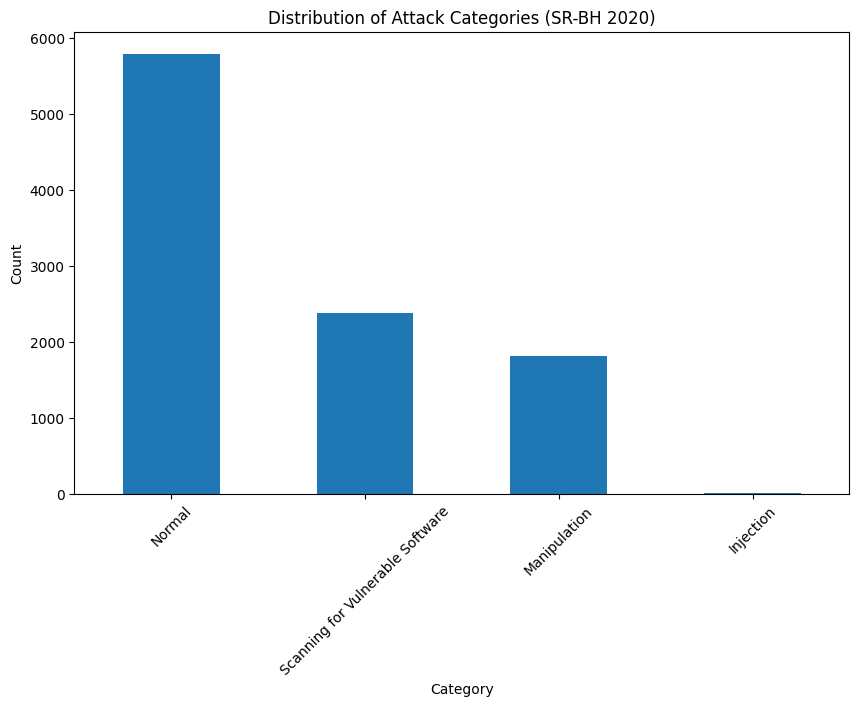

In [18]:
import matplotlib.pyplot as plt

# Plotting the categories
plt.figure(figsize=(10, 6))
df['category'].value_counts().plot(kind='bar')
plt.title('Distribution of Attack Categories (SR-BH 2020)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Payload Length Analysis

Since we are using DeBERTa-v3, the length of the text field matters. If payloads are extremely long, they will be truncated, potentially losing the malicious part of the string.

In [19]:
# Add a length column for analysis
df['payload_len'] = df['text'].str.len()

print("--- Payload Length Statistics ---")
print(df.groupby('category')['payload_len'].describe())

# Check for empty payloads
print(f"\nEmpty payloads: {df['text'].isna().sum()}")

--- Payload Length Statistics ---
                                   count        mean        std    min    25%  \
category                                                                        
Injection                            6.0  352.666667  32.922130  317.0  326.0   
Manipulation                      1816.0  356.104626  73.016841  193.0  306.0   
Normal                            5796.0  318.537440  75.861232  187.0  269.0   
Scanning for Vulnerable Software  2382.0  209.849706  11.181151  196.0  202.0   

                                    50%     75%    max  
category                                                
Injection                         354.0  367.00  403.0  
Manipulation                      360.0  377.25  623.0  
Normal                            294.0  346.00  723.0  
Scanning for Vulnerable Software  206.0  216.00  284.0  

Empty payloads: 0


#### Merged Parquet

In [51]:
!pwd
df = pd.read_parquet("../data/normalized/all_datasets.parquet")
print(f"--- Dataset: Combined---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))

with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    result = df.sample(45)
    display(result)

/home/ndelessy/Projects/ai-waf-v2/notebooks
--- Dataset: Combined---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
668377

--- Unique Categories ---
['benign' 'unknown' 'manipulation' 'injection'
 'scanning for vulnerable software' 'fake the source of data'
 'http abusion' 'dictionary-based password attack']

--- Unique Labels ---
[0 1]

--- Distribution (Counts) ---
                       attack_class  label   count
0                            benign      0  262509
1  dictionary-based password attack      1     306
2           fake the source of data      1   55982
3                      http abusion      1   23715
4                         injection      1  270450
5                      manipulation      1   27968
6  scanning for vulnerable software      1    2382
7                           unknown      1   25065


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
314148,f25c8f72-f928-42b5-8a0f-5e79a2f8a47e,GET,/blog/index.php%2560cat%2B%252Fetc%252Fpasswd%2560/my-account/edit-profile/%7B%7B%20data.sizes.full.url,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""User-Agent"": ""http://test-site.com/blog/index.php/my-account/edit-profile/%7B%7B%20data.sizes.full.url%20%7D%7D"", ""Referer"": ""comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=concept; wordpress_test_cookie=WP+Cookie+check"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog/index.php%2560cat%2B%252Fetc%252Fpasswd%2560/my-account/edit-profile/%7B%7B%20data.sizes.full.url HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nUser-Agent: http://test-site.com/blog/index.php/my-account/edit-profile/%7B%7B%20data.sizes.full.url%20%7D%7D\r\nReferer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; comment_author_1aefbe2f76edd740f8e362f39da3353b=concept; wordpress_test_cookie=WP+Cookie+check\r\nAccept-Language: Accept-Encoding\r\n,1,injection,SR-BH 2020,
637383,035af7dc-dcca-4ae6-b5be-9d36b23f1493,GET,/blog/index.php/comments/feed/,,"{""Content-Type"": ""Mozilla/5.0 (Windows NT 10.0; WOW64; Trident/7.0; Touch; MDDCJS; rv:11.0) like Gecko"", ""Accept"": ""*/*"", ""Accept-Language"": ""Accept-Encodinggzip, deflate""}",,"GET /blog/index.php/comments/feed/ HTTP/1.1\r\nContent-Type: Mozilla/5.0 (Windows NT 10.0; WOW64; Trident/7.0; Touch; MDDCJS; rv:11.0) like Gecko\r\nAccept: */*\r\nAccept-Language: Accept-Encodinggzip, deflate\r\n",0,benign,SR-BH 2020,
59539,ab232366-9a41-4f97-85f9-649175c43734,GET,http://localhost:8080/tienda1/publico/registro.jsp,modo=registro&login=legs&password=901gI5A&nombre=Di%F3genes&apellidos=Barcel%F3+Celada&email=%252B&dni=63732924Q&direccion=C%2F+Agustin+Lara%2C+120+2%3FD&ciudad=Terrinches&cp=08786&provincia=Burgos&ntc=6410780518660227&B1=Registrar HTTP/1.1,{},,GET http://localhost:8080/tienda1/publico/registro.jsp?modo=registro&login=legs&password=901gI5A&nombre=Di%F3genes&apellidos=Barcel%F3+Celada&email=%252B&dni=63732924Q&direccion=C%2F+Agustin+Lara%2C+120+2%3FD&ciudad=Terrinches&cp=08786&provincia=Burgos&ntc=6410780518660227&B1=Registrar HTTP/1.1 HTTP/1.1\r\n,1,unknown,CSIC 2010,
460633,c679fb04-3172-453b-ab8a-0e3d722c7049,GET,/blog/index.php/2020%27%29%29+UNION+ALL+SELECT+NULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL--+-,,"{""Content-Type"": ""Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0"", ""User-Agent"": ""http://test-site.com/"", ""Referer"": ""comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595186814%7CJXKR2dCAupLoAglXHclubbgwQJ4BL3zNKjxcob6dgUn%7Cfd5bc3380dc730cacaf855e46730c46b2fa753b2bb8d9f1096c95b5b8090acb3; comment_author_1aefbe2f76edd740f8e362f39da3353b=power; wordpress_test_cookie=WP+Cookie+check"", ""Accept-Language"": ""Accept-Encoding""}",,GET /blog/index.php/2020%27%29%29+UNION+ALL+SELECT+NULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL%2CNULL--+- HTTP/1.1\r\nContent-Type: Mozilla/5.0 (X11; Linux x86_64; rv:70.0) Gecko/20100101 Firefox/70.0\r\nUser-Agent: http://test-site.com/\r\nReferer: comment_author_url_1aefbe2f76edd740f8e362f39da3353b=http%3A%2F%2Fwww.example.com; comment_author_email_1aefbe2f76edd740f8e362f39da3353b=foo-bar%40example.com; wordpress_logged_in_1aefbe2f76edd740f8e362f39da3353b=rafael%7C1595186814%7CJXKR2dCAupLoAglXHclubbgwQJ4BL3zNKjxcob6dgUn%7Cfd5bc3380dc730cacaf855e46730c46b2fa753b2bb8d9f1096c95b5b8090acb3; comment_aut